# Dynamic Pricing - Retail Price Optimization

Notebook's structure:

Step 0: Setup & Configuration

Step 1: Load data + inspect + basic EDA

Step 2: Time-based train/test split

Step 3: Train data-driven demand model

Step 4: Data-driven environment

Step 5: DQN family benchmarks

Step 6: PPO (continuous pricing)

Step 7: Final results (DQN-family vs PPO)

### Setup & Configuration

In [4]:
import os, random, math, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import gymnasium as gym
    from gymnasium import spaces
    USING_GYMNASIUM = True
except ImportError:
    import gym
    from gym import spaces
    USING_GYMNASIUM = False


from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


import torch
import torch.nn as nn
import torch.optim as optim


SB3_OK = True
try:
    from stable_baselines3 import PPO
    from stable_baselines3.common.vec_env import DummyVecEnv
    from stable_baselines3.common.utils import set_random_seed
except Exception as e:
    SB3_OK = False
    print("Stable-Baselines3 not available. Install with: pip install stable-baselines3")
    print("Import error:", e)

def set_all_seeds(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)


DATA_PATH = Path("retail_price.csv")
assert DATA_PATH.exists(), f"Dataset not found: {DATA_PATH.resolve()}"


RUN_EDA = True
RUN_DEMAND_MODEL = True
RUN_ENV_SMOKE_TEST = True
RUN_DQN_BENCHMARK = True
RUN_PPO = True


# Global environment settings

TEST_MONTHS = 4
MAX_STEPS = 30

INITIAL_INVENTORY = 200
HOLDING_COST = 0.05
LIQUIDATION_PENALTY = 2.0


# Discrete pricing settings (DQN-family)

N_ACTIONS = 20
DQN_EPISODES = 300
EVAL_EPISODES = 30
SEEDS = [0, 1, 2, 3, 4]

# DQN hyperparams
GAMMA = 0.99
LR = 1e-3
BATCH_SIZE = 64
BUFFER_SIZE = 50_000
TARGET_UPDATE = 200
EPS_START = 1.0
EPS_END = 0.05
EPS_DECAY_STEPS = 10_000

# PPO settings
PPO_TIMESTEPS = 80_000

Device: cpu


### Step 1: Load data + inspect + basic EDA

Raw shape: (676, 30)


,product_id,product_category_name,month_year,qty,total_price,freight_price,unit_price,product_name_lenght,product_description_lenght,product_photos_qty,...,comp_1,ps1,fp1,comp_2,ps2,fp2,comp_3,ps3,fp3,lag_price
0,bed1,bed_bath_table,01-05-2017,1,45.95,15.100000,45.95,39,161,2,...,89.9,3.9,15.011897,215.000000,4.4,8.760000,45.95,4.0,15.100000,45.90
1,bed1,bed_bath_table,01-06-2017,3,137.85,12.933333,45.95,39,161,2,...,89.9,3.9,14.769216,209.000000,4.4,21.322000,45.95,4.0,12.933333,45.95
2,bed1,bed_bath_table,01-07-2017,6,275.70,14.840000,45.95,39,161,2,...,89.9,3.9,13.993833,205.000000,4.4,22.195932,45.95,4.0,14.840000,45.95
3,bed1,bed_bath_table,01-08-2017,4,183.80,14.287500,45.95,39,161,2,...,89.9,3.9,14.656757,199.509804,4.4,19.412885,45.95,4.0,14.287500,45.95
4,bed1,bed_bath_table,01-09-2017,2,91.90,15.100000,45.95,39,161,2,...,89.9,3.9,18.776522,163.398710,4.4,24.324687,45.95,4.0,15.100000,45.95



After parsing:
Shape: (676, 31)
Date range: 2017-01-01 00:00:00 → 2018-08-01 00:00:00
Unique products: 52


,product_id,product_category_name,month_year,qty,total_price,freight_price,unit_price,product_name_lenght,product_description_lenght,product_photos_qty,...,ps1,fp1,comp_2,ps2,fp2,comp_3,ps3,fp3,lag_price,date
0,bed1,bed_bath_table,01-05-2017,1,45.95,15.100000,45.95,39,161,2,...,3.9,15.011897,215.000000,4.4,8.760000,45.95,4.0,15.100000,45.90,2017-05-01
1,bed1,bed_bath_table,01-06-2017,3,137.85,12.933333,45.95,39,161,2,...,3.9,14.769216,209.000000,4.4,21.322000,45.95,4.0,12.933333,45.95,2017-06-01
2,bed1,bed_bath_table,01-07-2017,6,275.70,14.840000,45.95,39,161,2,...,3.9,13.993833,205.000000,4.4,22.195932,45.95,4.0,14.840000,45.95,2017-07-01
3,bed1,bed_bath_table,01-08-2017,4,183.80,14.287500,45.95,39,161,2,...,3.9,14.656757,199.509804,4.4,19.412885,45.95,4.0,14.287500,45.95,2017-08-01
4,bed1,bed_bath_table,01-09-2017,2,91.90,15.100000,45.95,39,161,2,...,3.9,18.776522,163.398710,4.4,24.324687,45.95,4.0,15.100000,45.95,2017-09-01



Missing values per column:


product_id                    0
year                          0
comp_avg                      0
date                          0
lag_price                     0
fp3                           0
ps3                           0
comp_3                        0
fp2                           0
ps2                           0
comp_2                        0
fp1                           0
ps1                           0
comp_1                        0
volume                        0
s                             0
month                         0
product_category_name         0
holiday                       0
weekend                       0
weekday                       0
customers                     0
product_score                 0
product_weight_g              0
product_photos_qty            0
product_description_lenght    0
product_name_lenght           0
unit_price                    0
freight_price                 0
total_price                   0
qty                           0
month_ye


Summary stats (numeric):


,unit_price,qty,comp_1,comp_2,comp_3,comp_avg,revenue_proxy
count,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000
mean,106.496800,14.495562,79.452054,92.930079,84.182642,85.521592,1422.220453
std,76.182972,15.443421,47.933358,49.481269,47.745789,40.499519,1699.375345
min,19.900000,1.000000,19.900000,19.900000,19.900000,19.900000,19.900000
25%,53.900000,4.000000,49.910000,53.900000,53.785714,55.425000,333.700000
50%,89.900000,10.000000,69.900000,89.990000,59.900000,68.266667,807.890000
75%,129.990000,18.000000,104.256549,117.888889,99.990000,116.950000,1887.322500
max,364.000000,122.000000,349.900000,349.900000,255.610000,255.610000,12095.000000


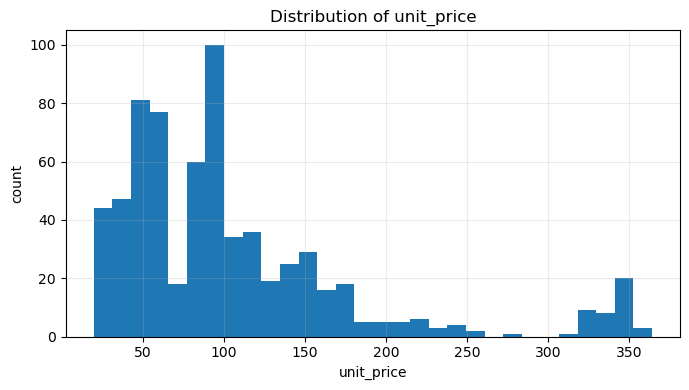

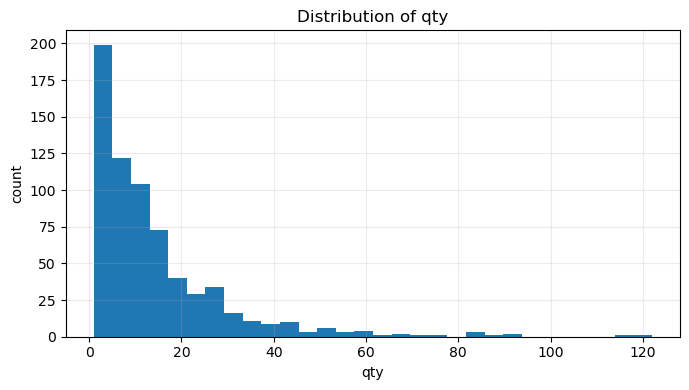

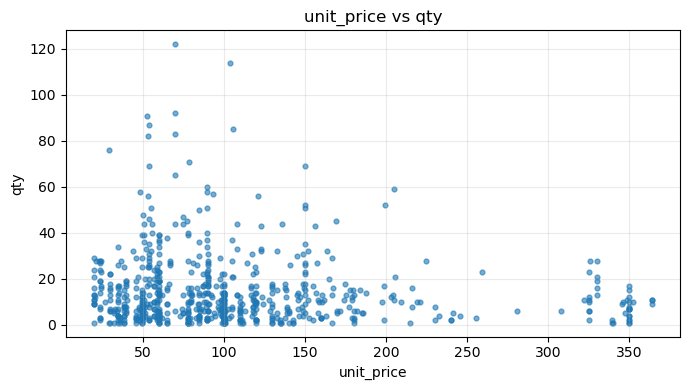

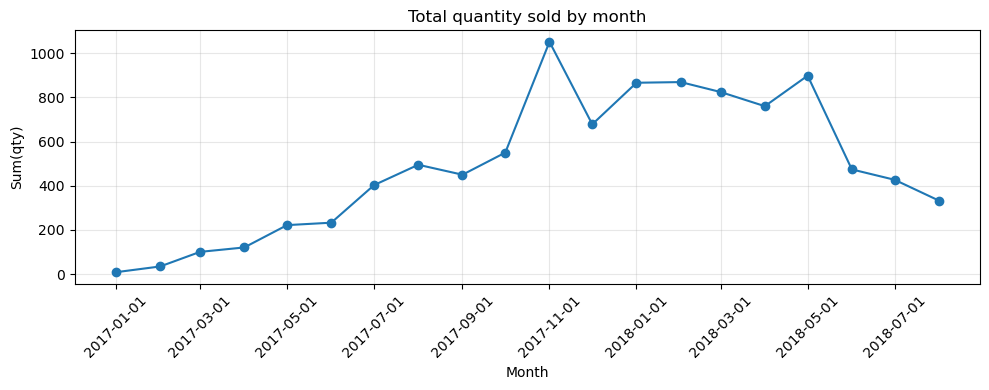

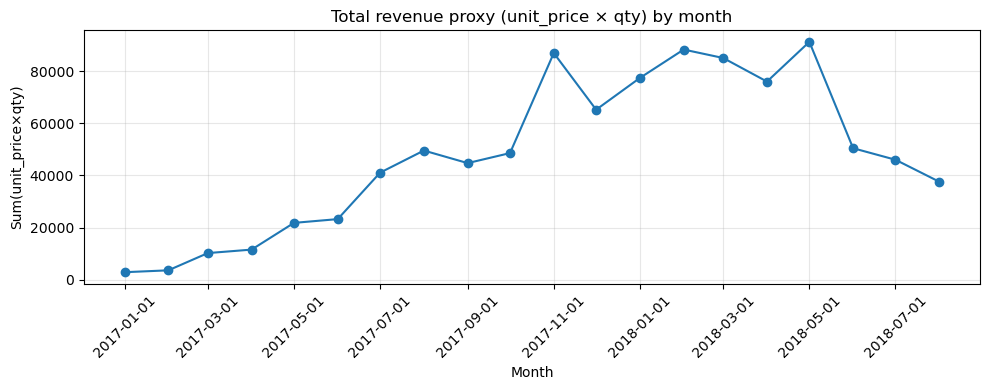

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


DATA_PATH = "retail_price.csv"   
df = pd.read_csv(DATA_PATH)

print("Raw shape:", df.shape)
display(df.head())


# Expecting columns (common in this dataset):
# product_id, year, month, unit_price, qty, comp_1, comp_2, comp_3
df.columns = [c.strip() for c in df.columns]

# Parse year/month into a real datetime "date"
# (Set day=1 for monthly data)
df["date"] = pd.to_datetime(dict(year=df["year"], month=df["month"], day=1))

# Basic types
num_cols = ["unit_price", "qty", "comp_1", "comp_2", "comp_3"]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["product_id"] = df["product_id"].astype(str)

# Sort for time-based analyses
df = df.sort_values(["product_id", "date"]).reset_index(drop=True)

print("\nAfter parsing:")
print("Shape:", df.shape)
print("Date range:", df["date"].min(), "→", df["date"].max())
print("Unique products:", df["product_id"].nunique())
display(df.head())


# 3) Create simple derived columns
df["comp_avg"] = df[["comp_1", "comp_2", "comp_3"]].mean(axis=1)
df["revenue_proxy"] = df["unit_price"] * df["qty"]

# Quick sanity checks
print("\nMissing values per column:")
display(df.isna().sum().sort_values(ascending=False))

print("\nSummary stats (numeric):")
display(df[["unit_price", "qty", "comp_1", "comp_2", "comp_3", "comp_avg", "revenue_proxy"]].describe())


# 4) EDA
# 4.1 Distribution of unit_price
plt.figure(figsize=(7, 4))
plt.hist(df["unit_price"].dropna(), bins=30)
plt.title("Distribution of unit_price")
plt.xlabel("unit_price")
plt.ylabel("count")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

# 4.2 Distribution of qty
plt.figure(figsize=(7, 4))
plt.hist(df["qty"].dropna(), bins=30)
plt.title("Distribution of qty")
plt.xlabel("qty")
plt.ylabel("count")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

# 4.3 Scatter: unit_price vs qty
plt.figure(figsize=(7, 4))
plt.scatter(df["unit_price"], df["qty"], s=12, alpha=0.6)
plt.title("unit_price vs qty")
plt.xlabel("unit_price")
plt.ylabel("qty")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

# 5) Monthly total
monthly = df.copy()
monthly["month_ts"] = monthly["date"].dt.to_period("M").dt.to_timestamp()

m = (monthly.groupby("month_ts", as_index=False)
     .agg(total_qty=("qty", "sum"),
          total_revenue=("revenue_proxy", "sum")))

# Total quantity by month
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(m["month_ts"], m["total_qty"], marker="o")
ax.set_title("Total quantity sold by month")
ax.set_xlabel("Month")
ax.set_ylabel("Sum(qty)")
ax.grid(True, alpha=0.3)

tick_step = max(1, len(m)//8)  # show ~8 ticks
ax.set_xticks(m["month_ts"].iloc[::tick_step])
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

# Total revenue proxy by month
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(m["month_ts"], m["total_revenue"], marker="o")
ax.set_title("Total revenue proxy (unit_price × qty) by month")
ax.set_xlabel("Month")
ax.set_ylabel("Sum(unit_price×qty)")
ax.grid(True, alpha=0.3)

ax.set_xticks(m["month_ts"].iloc[::tick_step])
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

### Step 2: Time-based train/test split

In [8]:
all_months = df["date"].sort_values().unique()
assert len(all_months) > TEST_MONTHS, "Not enough months for the requested test split."

cutoff = all_months[-TEST_MONTHS]  # start of test window
train_df = df[df["date"] < cutoff].reset_index(drop=True)
test_df  = df[df["date"] >= cutoff].reset_index(drop=True)

print("Train rows:", len(train_df), "| Train months:", train_df["date"].nunique())
print("Test rows :", len(test_df),  "| Test months :", test_df["date"].nunique())
print("Test starts:", cutoff)


split_summary = pd.DataFrame({
    "split": ["train", "test"],
    "rows": [len(train_df), len(test_df)],
    "months": [train_df["date"].nunique(), test_df["date"].nunique()],
    "date_min": [train_df["date"].min(), test_df["date"].min()],
    "date_max": [train_df["date"].max(), test_df["date"].max()],
})
display(split_summary)

Train rows: 516 | Train months: 16
Test rows : 160 | Test months : 4
Test starts: 2018-05-01 00:00:00


,split,rows,months,date_min,date_max
0,train,516,16,2017-01-01,2018-04-01
1,test,160,4,2018-05-01,2018-08-01


### Step 3: Train demand model

Numeric features: ['unit_price', 'lag_price', 'comp_1', 'comp_2', 'comp_3', 'customers', 'product_score', 'volume', 'freight_price', 'holiday', 'weekday', 'weekend', 'month', 'year']
Categorical features: ['product_id', 'product_category_name']


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


,RMSE,MAE,R2,sigma(residual_std)
0,13.259152,8.844202,0.209845,13.225


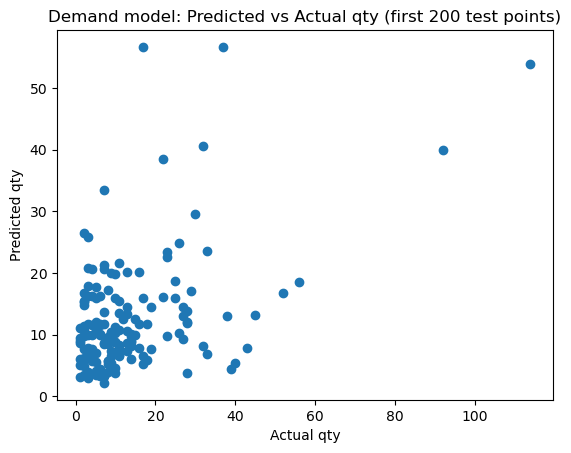

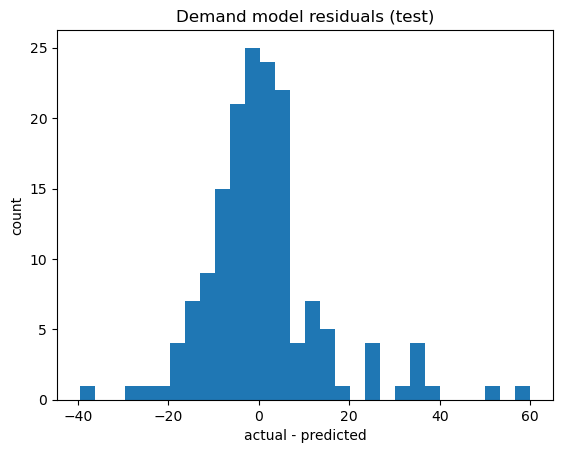

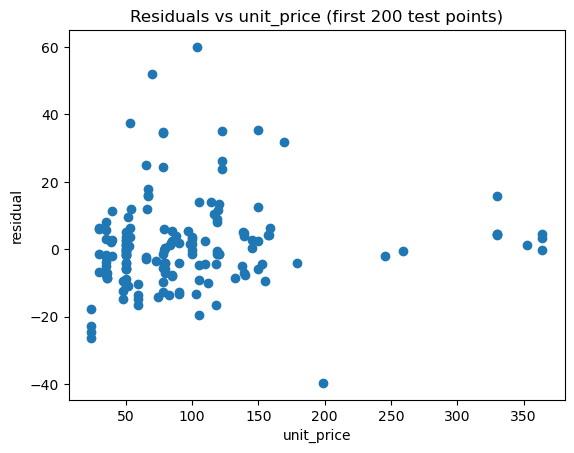

In [10]:
TARGET = "qty"

numeric_features = [
    "unit_price", "lag_price",
    "comp_1", "comp_2", "comp_3",
    "customers",
    "product_score", "volume",
    "freight_price",
    "holiday", "weekday", "weekend",
    "month", "year"
]
categorical_features = ["product_id", "product_category_name"]

num_use = [c for c in numeric_features if c in train_df.columns]
cat_use = [c for c in categorical_features if c in train_df.columns]
feature_cols = num_use + cat_use

print("Numeric features:", num_use)
print("Categorical features:", cat_use)

preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_use),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_use),
    ],
    remainder="drop"
)

demand_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", Ridge(alpha=1.0, random_state=42))
])

assert RUN_DEMAND_MODEL, "Set RUN_DEMAND_MODEL=True for the improved approach."

X_train = train_df[feature_cols].copy()
y_train = train_df[TARGET].copy()
X_test  = test_df[feature_cols].copy()
y_test  = test_df[TARGET].copy()

y_train_log = np.log1p(y_train)
demand_model.fit(X_train, y_train_log)

pred_log = demand_model.predict(X_test)
pred_qty = np.expm1(pred_log)
pred_qty = np.clip(pred_qty, 0, None)

rmse = mean_squared_error(y_test, pred_qty, squared=False)
mae  = mean_absolute_error(y_test, pred_qty)
r2   = r2_score(y_test, pred_qty)

residuals = (y_test - pred_qty)
demand_sigma = float(np.std(residuals))

metrics_df = pd.DataFrame([{
    "RMSE": rmse,
    "MAE": mae,
    "R2": r2,
    "sigma(residual_std)": demand_sigma
}])
display(metrics_df)

# Charts
plt.figure()
plt.scatter(y_test.values[:200], pred_qty[:200])
plt.title("Demand model: Predicted vs Actual qty (first 200 test points)")
plt.xlabel("Actual qty"); plt.ylabel("Predicted qty")
plt.show()

plt.figure()
plt.hist(residuals.values, bins=30)
plt.title("Demand model residuals (test)")
plt.xlabel("actual - predicted"); plt.ylabel("count")
plt.show()

if "unit_price" in test_df.columns:
    plt.figure()
    plt.scatter(test_df["unit_price"].values[:200], residuals.values[:200])
    plt.title("Residuals vs unit_price (first 200 test points)")
    plt.xlabel("unit_price"); plt.ylabel("residual")
    plt.show()



### Step 3B: Demand drivers

,feature,coef
60,product_id_watches3,-0.729888
43,product_id_garden7,-0.709226
33,product_id_furniture2,0.692822
15,product_id_bed2,0.669614
38,product_id_garden2,-0.633443
14,product_id_bed1,-0.533103
22,product_id_computers4,0.525061
40,product_id_garden4,0.470055
42,product_id_garden6,0.432519
19,product_id_computers1,-0.417906


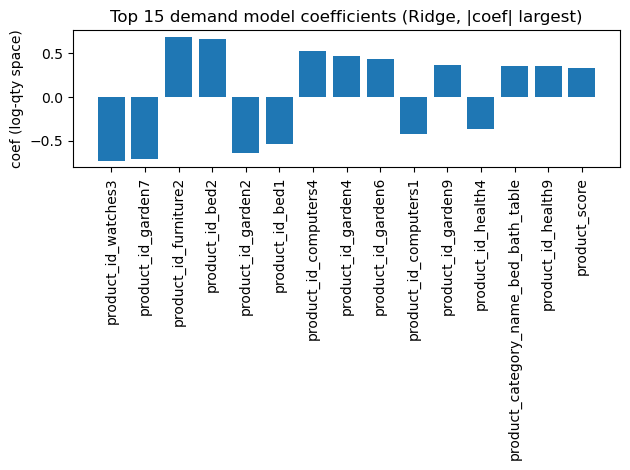

In [12]:
def get_feature_names_from_ct(ct: ColumnTransformer):
    names = []
    for name, trans, cols in ct.transformers_:
        if name == "remainder":
            continue
        if hasattr(trans, "get_feature_names_out"):
            try:
                out = list(trans.get_feature_names_out(cols))
                names.extend(out)
            except Exception:
                names.extend(list(cols))
        else:
            names.extend(list(cols))
    return names

ct = demand_model.named_steps["preprocess"]
ridge = demand_model.named_steps["model"]

feat_names = get_feature_names_from_ct(ct)
coefs = ridge.coef_

coef_df = pd.DataFrame({"feature": feat_names, "coef": coefs})
coef_df["abs_coef"] = coef_df["coef"].abs()
top = coef_df.sort_values("abs_coef", ascending=False).head(15)

display(top[["feature", "coef"]])

plt.figure()
plt.bar(range(len(top)), top["coef"].values)
plt.title("Top 15 demand model coefficients (Ridge, |coef| largest)")
plt.xticks(range(len(top)), top["feature"].values, rotation=90)
plt.ylabel("coef (log-qty space)")
plt.tight_layout()
plt.show()

### Step 4: Data-driven environment

In [14]:
def predict_demand_qty(model, context_row: dict, price: float, sigma: float, rng: np.random.Generator):
    row = context_row.copy()
    row["unit_price"] = float(price)
    X = pd.DataFrame([row])
    pred_log = float(model.predict(X)[0])
    qty_hat = float(np.expm1(pred_log))
    qty_hat = max(0.0, qty_hat)
    qty = qty_hat + float(rng.normal(0.0, sigma))
    qty = max(0.0, qty)
    return qty_hat, qty

class RetailPricingEnvDataDriven(gym.Env):
    """
    Data-driven environment:
    - sample a product_id
    - step through its time rows (up to MAX_STEPS)
    - demand = demand_model(context, chosen_price) + noise
    - reward = (revenue - variable_cost) - holding_cost - liquidation_penalty
    """
    metadata = {"render_modes": []}

    def __init__(
        self,
        data_df: pd.DataFrame,
        demand_model,
        demand_sigma: float,
        feature_cols: list,
        max_steps: int = 30,
        initial_inventory: float = 200,
        holding_cost: float = 0.05,
        liquidation_penalty: float = 2.0,
        seed: int = 42,
        discrete: bool = False,
        n_actions: int = 20,
    ):
        super().__init__()
        self.df = data_df.copy().sort_values(["product_id", "date"]).reset_index(drop=True)
        self.demand_model = demand_model
        self.demand_sigma = float(demand_sigma)
        self.feature_cols = feature_cols

        self.max_steps = int(max_steps)
        self.initial_inventory = float(initial_inventory)
        self.holding_cost = float(holding_cost)
        self.liquidation_penalty = float(liquidation_penalty)

        self.rng = np.random.default_rng(seed)

        self.min_price = float(self.df["unit_price"].min())
        self.max_price = float(self.df["unit_price"].max())

        self.discrete = bool(discrete)
        self.n_actions = int(n_actions)

        if self.discrete:
            self.action_space = spaces.Discrete(self.n_actions)
            self.price_grid = np.linspace(self.min_price, self.max_price, self.n_actions).astype(np.float32)
        else:
            self.action_space = spaces.Box(
                low=np.array([0.0], dtype=np.float32),
                high=np.array([1.0], dtype=np.float32),
                dtype=np.float32
            )

        # Observation: [inventory, month, year, last_price, comp_avg, customers, product_score]
        low = np.array([0, 1, 2010, self.min_price, 0, 0, 0], dtype=np.float32)
        high = np.array([1e9, 12, 2100, self.max_price, 1e9, 1e9, 1e9], dtype=np.float32)
        self.observation_space = spaces.Box(low=low, high=high, dtype=np.float32)

        # episode state
        self.product_id = None
        self.product_rows = None
        self.t = 0
        self.inventory = None
        self.last_price = None

    def _price_from_action(self, action):
        if self.discrete:
            idx = int(action)
            idx = max(0, min(self.n_actions - 1, idx))
            return float(self.price_grid[idx])
        a01 = float(action[0]) if isinstance(action, (np.ndarray, list)) else float(action)
        a01 = float(np.clip(a01, 0.0, 1.0))
        return self.min_price + a01 * (self.max_price - self.min_price)

    def _get_obs(self, row) -> np.ndarray:
        comp_avg = float(np.mean([row["comp_1"], row["comp_2"], row["comp_3"]]))
        obs = np.array([
            self.inventory,
            float(row["month"]),
            float(row["year"]),
            float(self.last_price),
            comp_avg,
            float(row["customers"]),
            float(row["product_score"]),
        ], dtype=np.float32)
        return obs

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.product_id = self.rng.choice(self.df["product_id"].unique())
        self.product_rows = self.df[self.df["product_id"] == self.product_id].reset_index(drop=True)

        self.t = 0
        self.inventory = float(self.initial_inventory)
        first = self.product_rows.iloc[0]
        self.last_price = float(first["lag_price"]) if "lag_price" in first else float(first["unit_price"])

        obs = self._get_obs(first)
        info = {"product_id": self.product_id}
        return obs, info

    def step(self, action):
        row = self.product_rows.iloc[self.t]
        price = self._price_from_action(action)

        context = {c: row[c] for c in self.feature_cols if c in row.index}
        qty_hat, qty = predict_demand_qty(self.demand_model, context, price, self.demand_sigma, self.rng)

        sales = min(qty, self.inventory)

        revenue = sales * price
        variable_cost = sales * float(row["freight_price"])
        profit = revenue - variable_cost

        self.inventory -= sales
        holding_cost = self.holding_cost * self.inventory
        reward = profit - holding_cost

        self.t += 1
        terminated = self.inventory <= 1e-6
        truncated = False

        if self.t >= min(self.max_steps, len(self.product_rows)):
            truncated = True
            if self.inventory > 0:
                reward -= self.liquidation_penalty * self.inventory

        self.last_price = price
        next_row = self.product_rows.iloc[min(self.t, len(self.product_rows) - 1)]
        obs = self._get_obs(next_row)

        info = {
            "product_id": self.product_id,
            "price": price,
            "qty_hat": float(qty_hat),
            "qty_realized": float(qty),
            "sales": float(sales),
            "inventory": float(self.inventory),
            "profit": float(profit),
            "holding_cost": float(holding_cost),
        }

        if USING_GYMNASIUM:
            return obs, float(reward), terminated, truncated, info
        else:
            done = terminated or truncated
            return obs, float(reward), done, info

def step_env(env, action):
    out = env.step(action)
    if len(out) == 5:
        obs, r, terminated, truncated, info = out
        return obs, r, (terminated or truncated), info
    else:
        obs, r, done, info = out
        return obs, r, done, info

### Step 4B: Smoke test environment

In [16]:

assert RUN_DEMAND_MODEL, "Demand model must be trained first."

if RUN_ENV_SMOKE_TEST:
    env = RetailPricingEnvDataDriven(
        data_df=train_df,
        demand_model=demand_model,
        demand_sigma=demand_sigma,
        feature_cols=feature_cols,
        max_steps=MAX_STEPS,
        initial_inventory=INITIAL_INVENTORY,
        holding_cost=HOLDING_COST,
        liquidation_penalty=LIQUIDATION_PENALTY,
        seed=42,
        discrete=True,
        n_actions=N_ACTIONS,
    )
    obs, info = env.reset()
    print("Reset OK. product_id:", info["product_id"])
    print("Initial obs:", obs)

    traj = []
    total_reward = 0.0
    for t in range(10):
        a = env.action_space.sample()
        obs, r, done, info = step_env(env, a)
        total_reward += r
        traj.append({
            "t": t,
            "action": a,
            "price": info["price"],
            "sales": info["sales"],
            "inventory": info["inventory"],
            "reward": r
        })
        if done:
            break

    display(pd.DataFrame(traj))
    print("Smoke test total_reward:", round(total_reward, 2))

Reset OK. product_id: bed5
Initial obs: [ 200.      5.   2017.    214.95  116.95   57.      4.4 ]


,t,action,price,sales,inventory,reward
0,0,9,176.215790,8.444773,191.555227,1404.548319
1,1,17,315.163147,15.851202,175.704025,4648.950209
2,2,16,297.794739,21.904612,153.799413,6029.194949
3,3,15,280.426331,0.000000,153.799413,-7.689971
4,4,9,176.215790,0.000000,153.799413,-315.288797


Smoke test total_reward: 11759.71


### Step 5: DQN-family benchmarks setup

In [18]:
#DQN-family components

class ReplayBuffer:
    def __init__(self, capacity: int, obs_dim: int):
        self.capacity = capacity
        self.ptr = 0
        self.size = 0
        self.obs = np.zeros((capacity, obs_dim), dtype=np.float32)
        self.next_obs = np.zeros((capacity, obs_dim), dtype=np.float32)
        self.acts = np.zeros((capacity,), dtype=np.int64)
        self.rews = np.zeros((capacity,), dtype=np.float32)
        self.dones = np.zeros((capacity,), dtype=np.float32)

    def add(self, o, a, r, no, d):
        self.obs[self.ptr] = o
        self.acts[self.ptr] = a
        self.rews[self.ptr] = r
        self.next_obs[self.ptr] = no
        self.dones[self.ptr] = d
        self.ptr = (self.ptr + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def sample(self, batch_size: int):
        idx = np.random.randint(0, self.size, size=batch_size)
        return (self.obs[idx], self.acts[idx], self.rews[idx], self.next_obs[idx], self.dones[idx])

class QNet(nn.Module):
    def __init__(self, obs_dim: int, n_actions: int, dueling: bool = False):
        super().__init__()
        self.dueling = dueling
        hidden = 128
        self.fc1 = nn.Linear(obs_dim, hidden)
        self.fc2 = nn.Linear(hidden, hidden)
        if dueling:
            self.v = nn.Linear(hidden, 1)
            self.a = nn.Linear(hidden, n_actions)
        else:
            self.q = nn.Linear(hidden, n_actions)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        if self.dueling:
            v = self.v(x)
            a = self.a(x)
            return v + (a - a.mean(dim=1, keepdim=True))
        else:
            return self.q(x)

def epsilon_by_step(step: int):
    if step >= EPS_DECAY_STEPS:
        return EPS_END
    frac = step / EPS_DECAY_STEPS
    return EPS_START + frac * (EPS_END - EPS_START)

def make_discrete_env(data_df, seed: int):
    return RetailPricingEnvDataDriven(
        data_df=data_df,
        demand_model=demand_model,
        demand_sigma=demand_sigma,
        feature_cols=feature_cols,
        max_steps=MAX_STEPS,
        initial_inventory=INITIAL_INVENTORY,
        holding_cost=HOLDING_COST,
        liquidation_penalty=LIQUIDATION_PENALTY,
        seed=seed,
        discrete=True,
        n_actions=N_ACTIONS,
    )


@torch.no_grad()
def eval_dqn_policy_with_kpis(env, qnet, n_episodes=30):
    qnet.eval()
    ep_rows = []
    ep_returns = []

    for ep in range(n_episodes):
        obs, info = env.reset()
        done = False
        total_r = 0.0

        prices, sales, invs, profits = [], [], [], []

        while not done:
            x = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
            q = qnet(x).squeeze(0)
            a = int(torch.argmax(q).item())

            obs, r, done, info = step_env(env, a)
            total_r += float(r)

            prices.append(float(info.get("price", np.nan)))
            sales.append(float(info.get("sales", np.nan)))
            invs.append(float(info.get("inventory", np.nan)))
            profits.append(float(info.get("profit", np.nan)))

       
        ep_returns.append(total_r)

        start_inv = float(INITIAL_INVENTORY)
        end_inv = float(invs[-1]) if invs else start_inv
        sold_units = start_inv - end_inv
        sell_through = sold_units / start_inv if start_inv > 0 else np.nan
        stockout = 1.0 if end_inv <= 1e-6 else 0.0

        ep_rows.append({
            "episode": ep,
            "total_reward": total_r,
            "avg_price": float(np.mean(prices)) if prices else np.nan,
            "min_price": float(np.min(prices)) if prices else np.nan,
            "max_price": float(np.max(prices)) if prices else np.nan,
            "sold_units": sold_units,
            "end_inventory": end_inv,
            "sell_through": sell_through,
            "stockout": stockout,
            "avg_profit": float(np.mean(profits)) if profits else np.nan,
        })

    kpi_df = pd.DataFrame(ep_rows)
    return float(np.mean(ep_returns)), float(np.std(ep_returns)), kpi_df


def train_dqn_variant(variant_name: str, seed: int):
    """
    variant_name in {"dqn","double","dueling","double_dueling"}
    """
    set_all_seeds(seed)

    train_env = make_discrete_env(train_df, seed)
    test_env  = make_discrete_env(test_df, seed)

    obs_dim = train_env.observation_space.shape[0]
    dueling = ("dueling" in variant_name)
    use_double = ("double" in variant_name)

    online = QNet(obs_dim, N_ACTIONS, dueling=dueling).to(DEVICE)
    target = QNet(obs_dim, N_ACTIONS, dueling=dueling).to(DEVICE)
    target.load_state_dict(online.state_dict())
    target.eval()

    optimizer = optim.Adam(online.parameters(), lr=LR)
    buffer = ReplayBuffer(BUFFER_SIZE, obs_dim)

    global_step = 0
    train_episode_rewards = []

    for ep in range(DQN_EPISODES):
        obs, info = train_env.reset()
        done = False
        ep_r = 0.0

        while not done:
            eps = epsilon_by_step(global_step)
            if np.random.rand() < eps:
                a = train_env.action_space.sample()
            else:
                x = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
                q = online(x).squeeze(0)
                a = int(torch.argmax(q).item())

            next_obs, r, done, info = step_env(train_env, a)
            buffer.add(obs, a, r, next_obs, float(done))
            obs = next_obs
            ep_r += r
            global_step += 1

            if buffer.size >= BATCH_SIZE:
                b_obs, b_act, b_rew, b_next, b_done = buffer.sample(BATCH_SIZE)

                b_obs_t = torch.tensor(b_obs, dtype=torch.float32, device=DEVICE)
                b_act_t = torch.tensor(b_act, dtype=torch.int64, device=DEVICE).unsqueeze(1)
                b_rew_t = torch.tensor(b_rew, dtype=torch.float32, device=DEVICE).unsqueeze(1)
                b_next_t = torch.tensor(b_next, dtype=torch.float32, device=DEVICE)
                b_done_t = torch.tensor(b_done, dtype=torch.float32, device=DEVICE).unsqueeze(1)

                q_sa = online(b_obs_t).gather(1, b_act_t)

                with torch.no_grad():
                    if use_double:
                        next_a = torch.argmax(online(b_next_t), dim=1, keepdim=True)
                        next_q = target(b_next_t).gather(1, next_a)
                    else:
                        next_q = torch.max(target(b_next_t), dim=1, keepdim=True)[0]

                    y = b_rew_t + GAMMA * (1.0 - b_done_t) * next_q

                loss = torch.mean((q_sa - y) ** 2)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                if global_step % TARGET_UPDATE == 0:
                    target.load_state_dict(online.state_dict())

        train_episode_rewards.append(ep_r)

    test_mean, test_std, test_kpis = eval_dqn_policy_with_kpis(test_env, online, n_episodes=EVAL_EPISODES)

    return {
        "variant": variant_name,
        "seed": seed,
        "train_rewards": train_episode_rewards,
        "test_mean": test_mean,
        "test_std": test_std,
        "test_kpis": test_kpis,
    }


### Step 5B: DQN family benchmarks results

DQN benchmark settings:
{'DQN_EPISODES': 300, 'EVAL_EPISODES': 30, 'SEEDS': [0, 1, 2, 3, 4], 'N_ACTIONS': 20, 'MAX_STEPS': 30, 'INITIAL_INVENTORY': 200, 'HOLDING_COST': 0.05, 'LIQUIDATION_PENALTY': 2.0}
TRAINING DQN | seed=0 | episodes=300
  -> TEST mean±std (30 eps): 7708.67 ± 6025.88
TRAINING DQN | seed=1 | episodes=300
  -> TEST mean±std (30 eps): 5011.50 ± 3908.84
TRAINING DQN | seed=2 | episodes=300
  -> TEST mean±std (30 eps): 7878.96 ± 5954.37
TRAINING DQN | seed=3 | episodes=300
  -> TEST mean±std (30 eps): 5986.36 ± 4757.11
TRAINING DQN | seed=4 | episodes=300
  -> TEST mean±std (30 eps): 6471.46 ± 3919.63
TRAINING DOUBLE | seed=0 | episodes=300
  -> TEST mean±std (30 eps): 7605.96 ± 5754.05
TRAINING DOUBLE | seed=1 | episodes=300
  -> TEST mean±std (30 eps): 4591.93 ± 3253.53
TRAINING DOUBLE | seed=2 | episodes=300
  -> TEST mean±std (30 eps): 7529.90 ± 5806.26
TRAINING DOUBLE | seed=3 | episodes=300
  -> TEST mean±std (30 eps): 6563.69 ± 5102.01
TRAINING DOUBLE | seed=4 | ep

,algo,seed,test_mean_reward,test_std_reward,avg_price_mean,sell_through_mean,end_inventory_mean,stockout_rate,avg_profit_mean
5,double,0,7605.962278,5754.050609,276.313208,0.155085,168.982993,0.0,2196.617077
6,double,1,4591.930438,3253.532024,256.628418,0.107112,178.577507,0.0,1303.447335
7,double,2,7529.895423,5806.256320,320.007477,0.131475,173.704970,0.0,2289.118181
8,double,3,6563.688911,5102.010169,354.107896,0.104780,179.044091,0.0,2362.485352
9,double,4,6643.918174,3633.293526,347.198336,0.107649,178.470268,0.0,2250.818732
15,double_dueling,0,7961.624984,6438.501508,346.104736,0.128191,174.361749,0.0,2216.361171
16,double_dueling,1,5144.489631,4064.097287,346.104736,0.086361,182.727757,0.0,1441.264602
17,double_dueling,2,7710.503189,6076.023938,323.437402,0.134664,173.067156,0.0,2323.776765
18,double_dueling,3,6074.421969,4939.391548,282.526841,0.123310,175.338023,0.0,2314.372351
19,double_dueling,4,6800.463540,3750.677302,364.000000,0.104611,179.077815,0.0,2268.519882



DQN-family summary across seeds (report-ready):


,algo,test_mean_avg,test_mean_std,avg_profit_mean,avg_price_mean,sell_through_mean,end_inventory_mean,stockout_rate
1,double_dueling,6738.300663,1164.745991,2112.858954,332.434743,0.115428,176.914500,0.0
3,dueling,6729.005372,1014.126447,2136.397283,327.931102,0.118578,176.284500,0.0
2,dqn,6611.390413,1202.150127,2139.304793,305.721091,0.126513,174.697356,0.0
0,double,6587.079045,1215.670753,2080.497335,310.851067,0.121220,175.755966,0.0


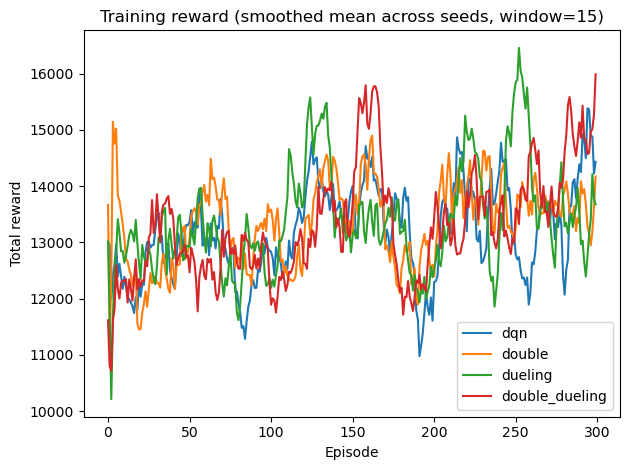

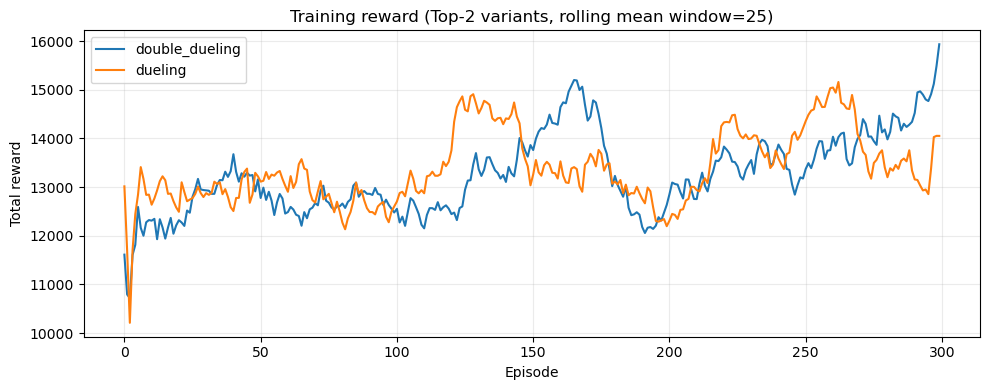

,algo,lastK_mean_avg,lastK_mean_std
3,double_dueling,14988.293945,831.975708
1,double,13785.419922,1634.660400
0,dqn,13677.312500,697.057739
2,dueling,13613.328125,546.580933


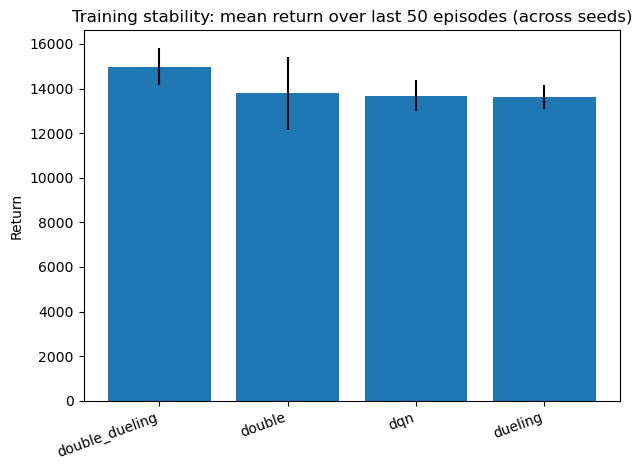

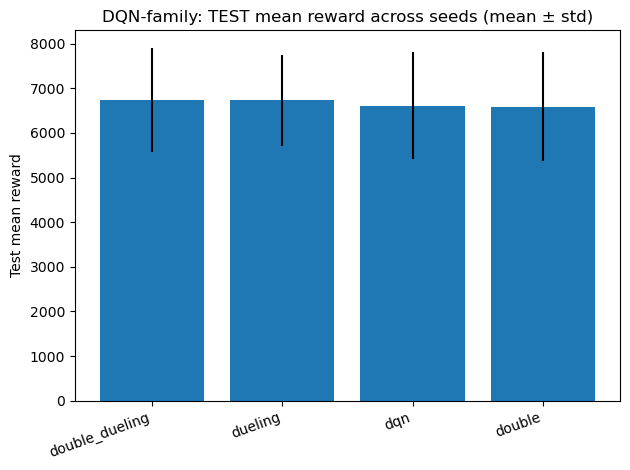

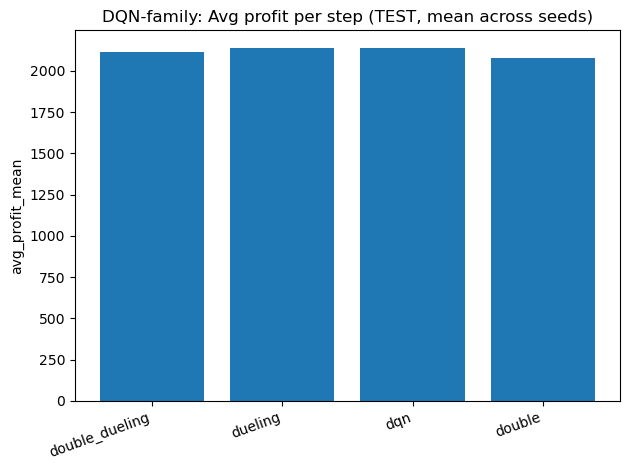

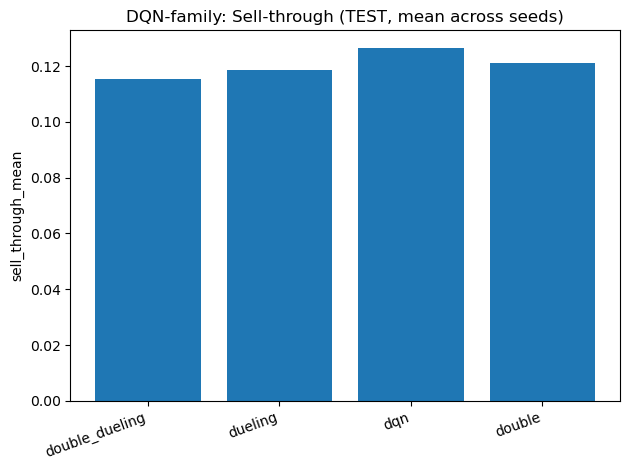

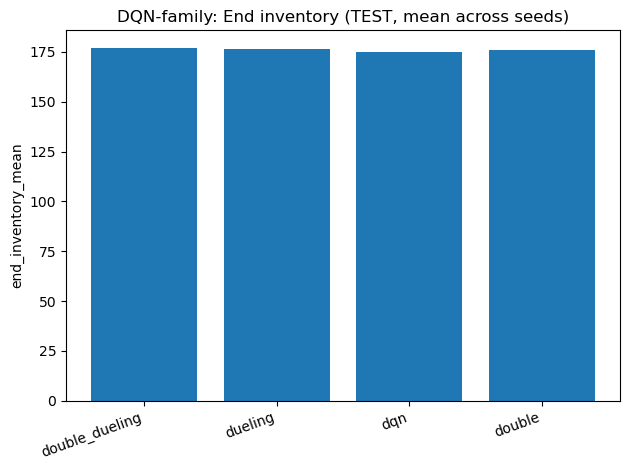

In [20]:
variants = ["dqn", "double", "dueling", "double_dueling"]
all_runs = []

print("DQN benchmark settings:")
print({
    "DQN_EPISODES": DQN_EPISODES,
    "EVAL_EPISODES": EVAL_EPISODES,
    "SEEDS": SEEDS,
    "N_ACTIONS": N_ACTIONS,
    "MAX_STEPS": MAX_STEPS,
    "INITIAL_INVENTORY": INITIAL_INVENTORY,
    "HOLDING_COST": HOLDING_COST,
    "LIQUIDATION_PENALTY": LIQUIDATION_PENALTY
})

t0 = time.time()

for v in variants:
    for s in SEEDS:
        print("=" * 70)
        print(f"TRAINING {v.upper()} | seed={s} | episodes={DQN_EPISODES}")
        out = train_dqn_variant(v, s)
        all_runs.append(out)
        print(f"  -> TEST mean±std ({EVAL_EPISODES} eps): {out['test_mean']:.2f} ± {out['test_std']:.2f}")

print("\nElapsed minutes:", round((time.time() - t0) / 60, 2))

# 1) Build one per-seed table (reward + KPIs)

rows = []
for r in all_runs:
    kdf = r["test_kpis"]

    rows.append({
        "algo": r["variant"],
        "seed": r["seed"],
        "test_mean_reward": float(r["test_mean"]),
        "test_std_reward": float(r["test_std"]),
        "avg_price_mean": float(kdf["avg_price"].mean()),
        "sell_through_mean": float(kdf["sell_through"].mean()),
        "end_inventory_mean": float(kdf["end_inventory"].mean()),
        "stockout_rate": float(kdf["stockout"].mean()),
        "avg_profit_mean": float(kdf["avg_profit"].mean()),
    })

dqn_df = pd.DataFrame(rows)

print("\nDQN-family per-seed results (reward + KPIs):")
display(dqn_df.sort_values(["algo", "seed"]))

# 2) Summary across seeds
dqn_summary = (dqn_df.groupby("algo")
              .agg(
                  test_mean_avg=("test_mean_reward", "mean"),
                  test_mean_std=("test_mean_reward", "std"),
                  avg_profit_mean=("avg_profit_mean", "mean"),
                  avg_price_mean=("avg_price_mean", "mean"),
                  sell_through_mean=("sell_through_mean", "mean"),
                  end_inventory_mean=("end_inventory_mean", "mean"),
                  stockout_rate=("stockout_rate", "mean"),
              )
              .reset_index()
              .sort_values("test_mean_avg", ascending=False))

print("\nDQN-family summary across seeds (report-ready):")
display(dqn_summary)


# 2) Training curve chart 

SMOOTH_W = 15  

plt.figure()
for v in variants:
    curves = np.array([r["train_rewards"] for r in all_runs if r["variant"] == v], dtype=np.float32)
    mean_curve = curves.mean(axis=0)
    smooth = pd.Series(mean_curve).rolling(window=SMOOTH_W, min_periods=1).mean().values
    plt.plot(smooth, label=v)

plt.title(f"Training reward (smoothed mean across seeds, window={SMOOTH_W})")
plt.xlabel("Episode")
plt.ylabel("Total reward")
plt.legend()
plt.tight_layout()
plt.show()

SMOOTH_W = 25  
top2 = dqn_summary.sort_values("test_mean_avg", ascending=False)["algo"].head(2).tolist()

plt.figure(figsize=(10, 4))
for v in top2:
    curves = np.array([r["train_rewards"] for r in all_runs if r["variant"] == v], dtype=np.float32)
    mean_curve = curves.mean(axis=0)
    smooth = pd.Series(mean_curve).rolling(window=SMOOTH_W, min_periods=1).mean().values
    plt.plot(smooth, label=v)

plt.title(f"Training reward (Top-2 variants, rolling mean window={SMOOTH_W})")
plt.xlabel("Episode")
plt.ylabel("Total reward")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()



# Stability chart: average return in last K episodes (across seeds)

K = 50
lastk_rows = []
for v in variants:
    curves = np.array([r["train_rewards"] for r in all_runs if r["variant"] == v], dtype=np.float32)
    last_k_mean_per_seed = curves[:, -K:].mean(axis=1)
    lastk_rows.append({
        "algo": v,
        "lastK_mean_avg": float(last_k_mean_per_seed.mean()),
        "lastK_mean_std": float(last_k_mean_per_seed.std()),
    })

lastk_df = pd.DataFrame(lastk_rows).sort_values("lastK_mean_avg", ascending=False)
display(lastk_df)

plt.figure()
x = np.arange(len(lastk_df))
plt.bar(x, lastk_df["lastK_mean_avg"].values, yerr=lastk_df["lastK_mean_std"].values)
plt.xticks(x, lastk_df["algo"].values, rotation=20, ha="right")
plt.title(f"Training stability: mean return over last {K} episodes (across seeds)")
plt.ylabel("Return")
plt.tight_layout()
plt.show()


# 4) TEST reward

plt.figure()
x = np.arange(len(dqn_summary))
plt.bar(x, dqn_summary["test_mean_avg"].values, yerr=dqn_summary["test_mean_std"].values)
plt.title("DQN-family: TEST mean reward across seeds (mean ± std)")
plt.xticks(x, dqn_summary["algo"].values, rotation=20, ha="right")
plt.ylabel("Test mean reward")
plt.tight_layout()
plt.show()


# 5) KPI

plt.figure()
plt.bar(dqn_summary["algo"].values, dqn_summary["avg_profit_mean"].values)
plt.title("DQN-family: Avg profit per step (TEST, mean across seeds)")
plt.ylabel("avg_profit_mean")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

plt.figure()
plt.bar(dqn_summary["algo"].values, dqn_summary["sell_through_mean"].values)
plt.title("DQN-family: Sell-through (TEST, mean across seeds)")
plt.ylabel("sell_through_mean")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

plt.figure()
plt.bar(dqn_summary["algo"].values, dqn_summary["end_inventory_mean"].values)
plt.title("DQN-family: End inventory (TEST, mean across seeds)")
plt.ylabel("end_inventory_mean")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

### Step 6: PPO (continuous pricing)

PPO settings:
{'PPO_TIMESTEPS': 80000, 'EVAL_EPISODES': 30, 'SEEDS': [0, 1, 2, 3, 4], 'MAX_STEPS': 30, 'INITIAL_INVENTORY': 200, 'HOLDING_COST': 0.05, 'LIQUIDATION_PENALTY': 2.0}
TRAINING PPO | seed=0 | total_timesteps=80000
[PPO | seed=0] TEST mean±std (30 eps): 8,115.28 ± 6,648.04
Seed KPI snapshot: {'avg_price_mean': 364.0, 'sell_through_mean': 0.1238, 'end_inventory_mean': 175.2434, 'stockout_rate': 0.0, 'avg_profit_mean': 2239.9939}
TRAINING PPO | seed=1 | total_timesteps=80000
[PPO | seed=1] TEST mean±std (30 eps): 5,324.13 ± 4,270.82
Seed KPI snapshot: {'avg_price_mean': 364.0, 'sell_through_mean': 0.0845, 'end_inventory_mean': 183.1006, 'stockout_rate': 0.0, 'avg_profit_mean': 1488.2395}
TRAINING PPO | seed=2 | total_timesteps=80000
[PPO | seed=2] TEST mean±std (30 eps): 7,931.04 ± 5,939.31
Seed KPI snapshot: {'avg_price_mean': 364.0, 'sell_through_mean': 0.1204, 'end_inventory_mean': 175.9196, 'stockout_rate': 0.0, 'avg_profit_mean': 2365.9098}
TRAINING PPO | seed=3 | total_ti

,algo,seed,test_mean_reward,test_std_reward,avg_price_mean,sell_through_mean,end_inventory_mean,stockout_rate,avg_profit_mean
0,PPO,0,8115.278220,6648.044473,364.0,0.123783,175.243374,0.0,2239.993933
1,PPO,1,5324.128153,4270.818692,364.0,0.084497,183.100568,0.0,1488.239488
2,PPO,2,7931.036916,5939.307151,364.0,0.120402,175.919582,0.0,2365.909783
3,PPO,3,6590.512373,5254.781581,364.0,0.102220,179.555945,0.0,2352.939747
4,PPO,4,6800.463540,3750.677302,364.0,0.104611,179.077815,0.0,2268.519882



PPO summary across seeds (report-ready):


,algo,test_mean_avg,test_mean_std,avg_profit_mean,avg_price_mean,sell_through_mean,end_inventory_mean,stockout_rate
0,PPO,6952.28384,1130.855036,2143.120567,364.0,0.107103,178.579457,0.0


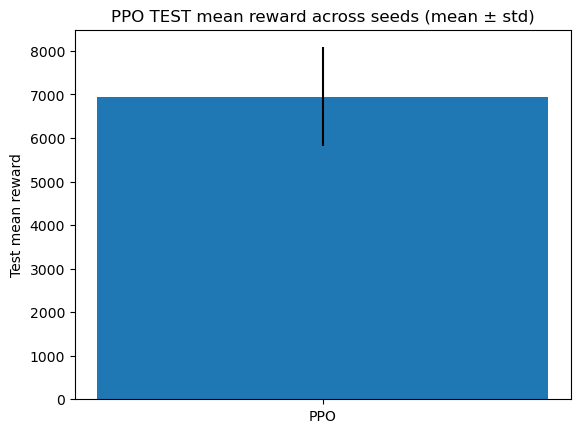

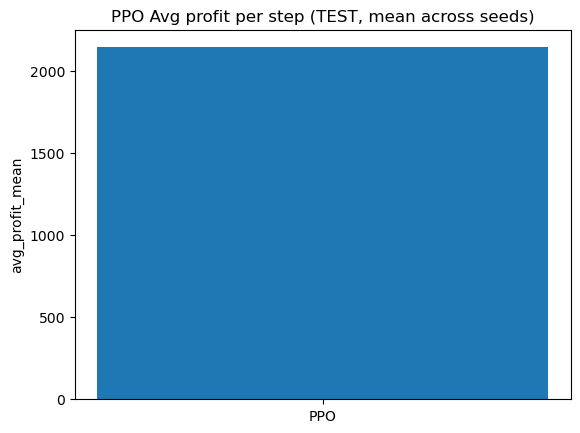

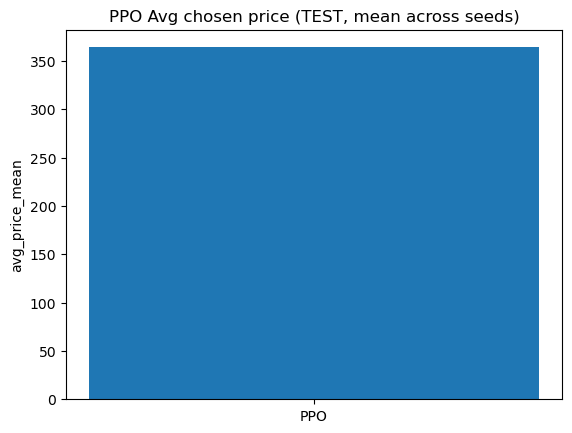

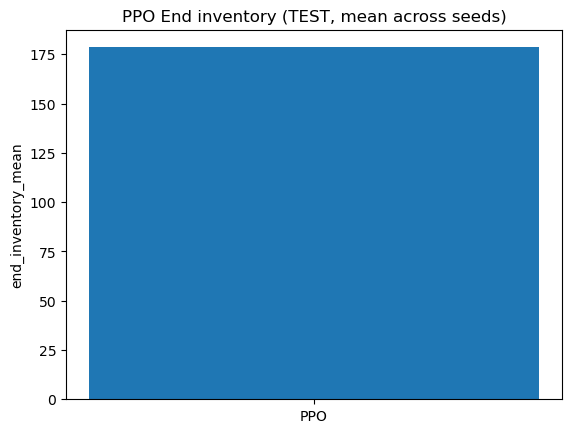

In [22]:
assert SB3_OK, "Stable-Baselines3 missing. Install: pip install stable-baselines3"

print("PPO settings:")
print({
    "PPO_TIMESTEPS": PPO_TIMESTEPS,
    "EVAL_EPISODES": EVAL_EPISODES,
    "SEEDS": SEEDS,
    "MAX_STEPS": MAX_STEPS,
    "INITIAL_INVENTORY": INITIAL_INVENTORY,
    "HOLDING_COST": HOLDING_COST,
    "LIQUIDATION_PENALTY": LIQUIDATION_PENALTY
})

def make_continuous_env(data_df, seed: int):
    
    return RetailPricingEnvDataDriven(
        data_df=data_df,
        demand_model=demand_model,
        demand_sigma=demand_sigma,
        feature_cols=feature_cols,
        max_steps=MAX_STEPS,
        initial_inventory=INITIAL_INVENTORY,
        holding_cost=HOLDING_COST,
        liquidation_penalty=LIQUIDATION_PENALTY,
        seed=seed,
        discrete=False,
        n_actions=N_ACTIONS,
    )

def eval_sb3_with_kpis(env, model, n_episodes: int = 30):
    ep_rows = []
    ep_returns = []

    for ep in range(n_episodes):
        obs, info = env.reset()
        done = False
        total_r = 0.0

        prices, sales, invs, profits = [], [], [], []

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, r, done, info = step_env(env, action)

            total_r += float(r)
            prices.append(float(info.get("price", np.nan)))
            sales.append(float(info.get("sales", np.nan)))
            invs.append(float(info.get("inventory", np.nan)))
            profits.append(float(info.get("profit", np.nan)))

        
        ep_returns.append(total_r)

        start_inv = float(INITIAL_INVENTORY)
        end_inv = float(invs[-1]) if invs else start_inv
        sold_units = start_inv - end_inv
        sell_through = sold_units / start_inv if start_inv > 0 else np.nan
        stockout = 1.0 if end_inv <= 1e-6 else 0.0

        ep_rows.append({
            "episode": ep,
            "total_reward": total_r,
            "avg_price": float(np.mean(prices)) if prices else np.nan,
            "min_price": float(np.min(prices)) if prices else np.nan,
            "max_price": float(np.max(prices)) if prices else np.nan,
            "sold_units": sold_units,
            "end_inventory": end_inv,
            "sell_through": sell_through,
            "stockout": stockout,
            "avg_profit": float(np.mean(profits)) if profits else np.nan,
        })

    kpi_df = pd.DataFrame(ep_rows)
    return float(np.mean(ep_returns)), float(np.std(ep_returns)), kpi_df



# Train + Evaluate PPO across multiple seeds

ppo_runs = []
t0 = time.time()

for seed in SEEDS:
    # global reproducibility
    set_all_seeds(seed)
    set_random_seed(seed)

    # training uses DummyVecEnv (SB3 requirement)
    train_vec = DummyVecEnv([lambda s=seed: make_continuous_env(train_df, s)])
    test_env = make_continuous_env(test_df, seed)

    model = PPO(
        policy="MlpPolicy",
        env=train_vec,
        seed=seed,
        verbose=0,
        n_steps=2048,
        batch_size=64,
        gamma=0.99,
        learning_rate=3e-4,
        ent_coef=0.0,
        clip_range=0.2,
    )

    print("=" * 70)
    print(f"TRAINING PPO | seed={seed} | total_timesteps={PPO_TIMESTEPS}")
    model.learn(total_timesteps=PPO_TIMESTEPS, reset_num_timesteps=True)

    test_mean, test_std, test_kpis = eval_sb3_with_kpis(test_env, model, n_episodes=EVAL_EPISODES)

    # summarize KPIs for this seed 
    kpi_seed = {
        "avg_price_mean": float(test_kpis["avg_price"].mean()),
        "sell_through_mean": float(test_kpis["sell_through"].mean()),
        "end_inventory_mean": float(test_kpis["end_inventory"].mean()),
        "stockout_rate": float(test_kpis["stockout"].mean()),
        "avg_profit_mean": float(test_kpis["avg_profit"].mean()),
    }

    ppo_runs.append({
        "algo": "PPO",
        "seed": seed,
        "test_mean_reward": test_mean,
        "test_std_reward": test_std,
        **kpi_seed,
        "episode_kpis_df": test_kpis
    })

    print(f"[PPO | seed={seed}] TEST mean±std ({EVAL_EPISODES} eps): {test_mean:,.2f} ± {test_std:,.2f}")
    print("Seed KPI snapshot:", {k: round(v, 4) for k, v in kpi_seed.items()})

print("\nElapsed minutes:", round((time.time() - t0) / 60, 2))

# Tables
ppo_df = pd.DataFrame([{
    "algo": r["algo"],
    "seed": r["seed"],
    "test_mean_reward": r["test_mean_reward"],
    "test_std_reward": r["test_std_reward"],
    "avg_price_mean": r["avg_price_mean"],
    "sell_through_mean": r["sell_through_mean"],
    "end_inventory_mean": r["end_inventory_mean"],
    "stockout_rate": r["stockout_rate"],
    "avg_profit_mean": r["avg_profit_mean"],
} for r in ppo_runs])

print("\nPPO per-seed results (reward + KPIs):")
display(ppo_df)

ppo_summary = (ppo_df.groupby("algo")
               .agg(
                   test_mean_avg=("test_mean_reward", "mean"),
                   test_mean_std=("test_mean_reward", "std"),
                   avg_profit_mean=("avg_profit_mean", "mean"),
                   avg_price_mean=("avg_price_mean", "mean"),
                   sell_through_mean=("sell_through_mean", "mean"),
                   end_inventory_mean=("end_inventory_mean", "mean"),
                   stockout_rate=("stockout_rate", "mean"),
               )
               .reset_index())

print("\nPPO summary across seeds (report-ready):")
display(ppo_summary)



# Reward chart
plt.figure()
plt.bar(["PPO"], ppo_summary["test_mean_avg"].values, yerr=ppo_summary["test_mean_std"].values)
plt.title("PPO TEST mean reward across seeds (mean ± std)")
plt.ylabel("Test mean reward")
plt.show()

# Profit / price / inventory charts
plt.figure()
plt.bar(["PPO"], ppo_summary["avg_profit_mean"].values)
plt.title("PPO Avg profit per step (TEST, mean across seeds)")
plt.ylabel("avg_profit_mean")
plt.show()

plt.figure()
plt.bar(["PPO"], ppo_summary["avg_price_mean"].values)
plt.title("PPO Avg chosen price (TEST, mean across seeds)")
plt.ylabel("avg_price_mean")
plt.show()

plt.figure()
plt.bar(["PPO"], ppo_summary["end_inventory_mean"].values)
plt.title("PPO End inventory (TEST, mean across seeds)")
plt.ylabel("end_inventory_mean")
plt.show()

### Step 7: Final comparison table (DQN-family vs PPO)


FINAL RESULTS (Reward + KPIs, TEST, mean ± std across seeds)


,algo,test_mean_avg,test_mean_std,avg_profit_mean,avg_price_mean,sell_through_mean,end_inventory_mean,stockout_rate,sell_through_%
0,PPO,6952.283840,1130.855036,2143.120567,364.000000,0.107103,178.579457,0.0,10.710272
1,double_dueling,6738.300663,1164.745991,2112.858954,332.434743,0.115428,176.914500,0.0,11.542750
2,dueling,6729.005372,1014.126447,2136.397283,327.931102,0.118578,176.284500,0.0,11.857750
3,dqn,6611.390413,1202.150127,2139.304793,305.721091,0.126513,174.697356,0.0,12.651322
4,double,6587.079045,1215.670753,2080.497335,310.851067,0.121220,175.755966,0.0,12.122017


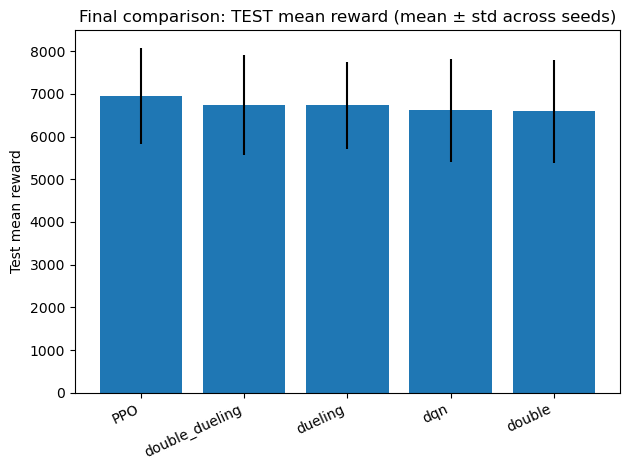

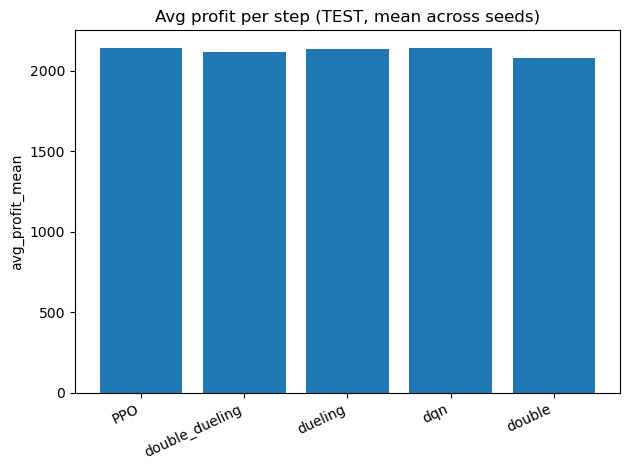

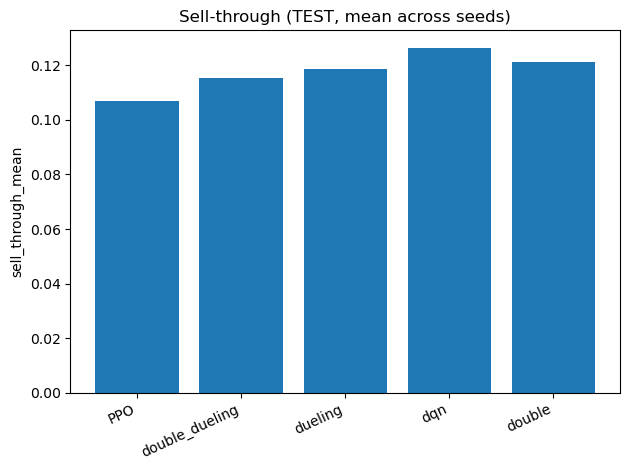

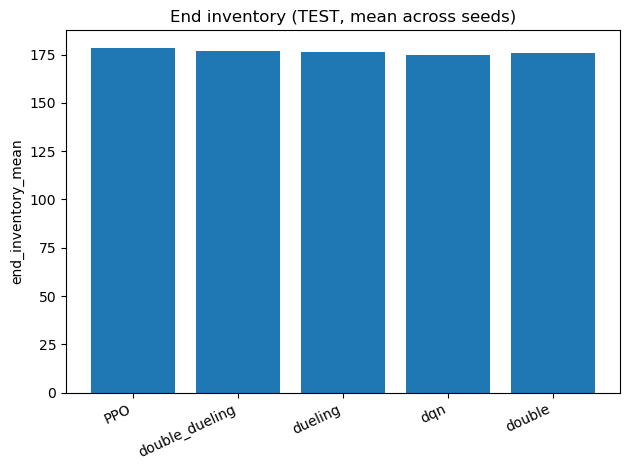

In [24]:

use_dqn_summary = "dqn_summary" in globals()

if use_dqn_summary:
    dqn_block = dqn_summary.rename(columns={"algo": "algo"}).copy()
   
else:
    dqn_reward = summary_df.rename(columns={"variant": "algo"}).copy()
    dqn_kpis   = kpi_summary.rename(columns={"variant": "algo"}).copy()
    dqn_block  = pd.merge(dqn_reward, dqn_kpis, on="algo", how="inner")


ppo_reward = ppo_summary.rename(columns={"variant": "algo"}).copy()

if "avg_profit_mean" in ppo_reward.columns:
    ppo_block = ppo_reward.copy()
else:
    ppo_kpis = ppo_kpi_summary.rename(columns={"variant": "algo"}).copy()
    if "seed" in ppo_kpis.columns:
        ppo_kpis = ppo_kpis.drop(columns=["seed"])
    ppo_block = pd.merge(ppo_reward, ppo_kpis, on="algo", how="inner")

# Final comparison

common_cols = [
    "algo",
    "test_mean_avg", "test_mean_std",
    "avg_profit_mean",
    "avg_price_mean",
    "sell_through_mean",
    "end_inventory_mean",
    "stockout_rate",
]

final_cols = [c for c in common_cols if (c in dqn_block.columns and c in ppo_block.columns)]

final = pd.concat([
    dqn_block[final_cols],
    ppo_block[final_cols]
], ignore_index=True)

if "sell_through_mean" in final.columns:
    final["sell_through_%"] = 100.0 * final["sell_through_mean"]

final = final.sort_values("test_mean_avg", ascending=False).reset_index(drop=True)

print("\nFINAL RESULTS (Reward + KPIs, TEST, mean ± std across seeds)")
display(final)

# Chart 1: Reward (mean ± std)

plt.figure()
x = np.arange(len(final))
plt.bar(x, final["test_mean_avg"].values, yerr=final["test_mean_std"].values)
plt.title("Final comparison: TEST mean reward (mean ± std across seeds)")
plt.xticks(x, final["algo"].values, rotation=25, ha="right")
plt.ylabel("Test mean reward")
plt.tight_layout()
plt.show()


# Chart 2: Profit per step (business KPI)
if "avg_profit_mean" in final.columns:
    plt.figure()
    plt.bar(final["algo"].values, final["avg_profit_mean"].values)
    plt.title("Avg profit per step (TEST, mean across seeds)")
    plt.ylabel("avg_profit_mean")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()


# Chart 3: Sell-through and End inventory (business behavior)

if "sell_through_mean" in final.columns:
    plt.figure()
    plt.bar(final["algo"].values, final["sell_through_mean"].values)
    plt.title("Sell-through (TEST, mean across seeds)")
    plt.ylabel("sell_through_mean")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()

if "end_inventory_mean" in final.columns:
    plt.figure()
    plt.bar(final["algo"].values, final["end_inventory_mean"].values)
    plt.title("End inventory (TEST, mean across seeds)")
    plt.ylabel("end_inventory_mean")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()